In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

In [6]:
tumor_gsea_results=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Results/csvs/gsea_report_for_High_P_High_C_Tumor.tsv", sep="\t")
raw_gsea_results=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Results/csvs/gsea_report_for_High_P_High_C_Bulk.tsv", sep="\t")

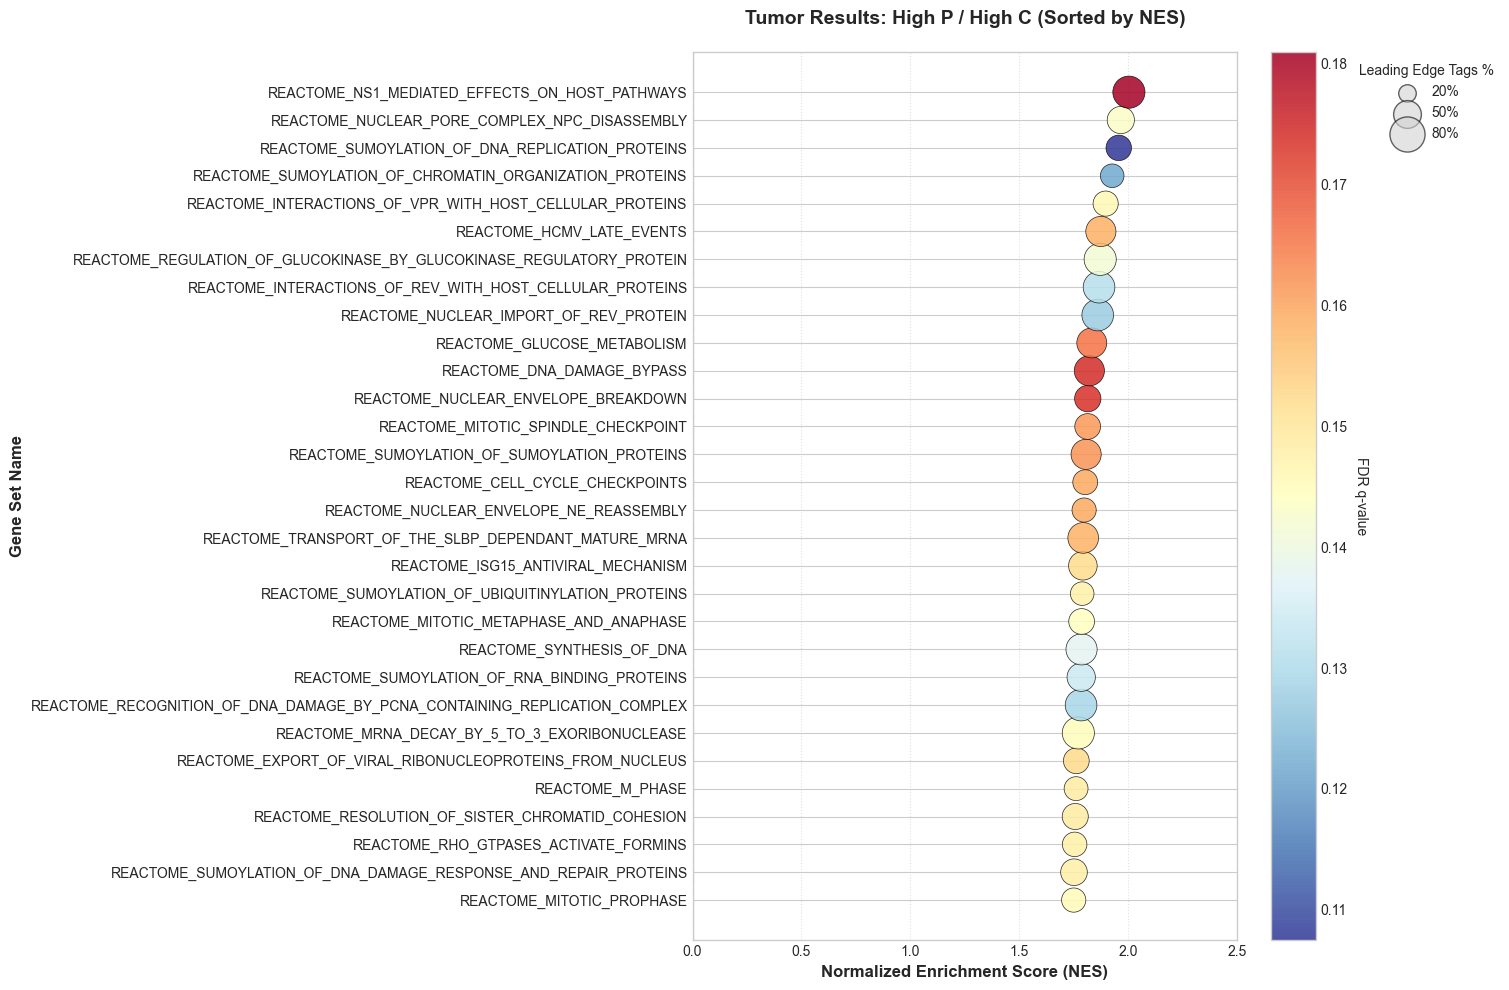

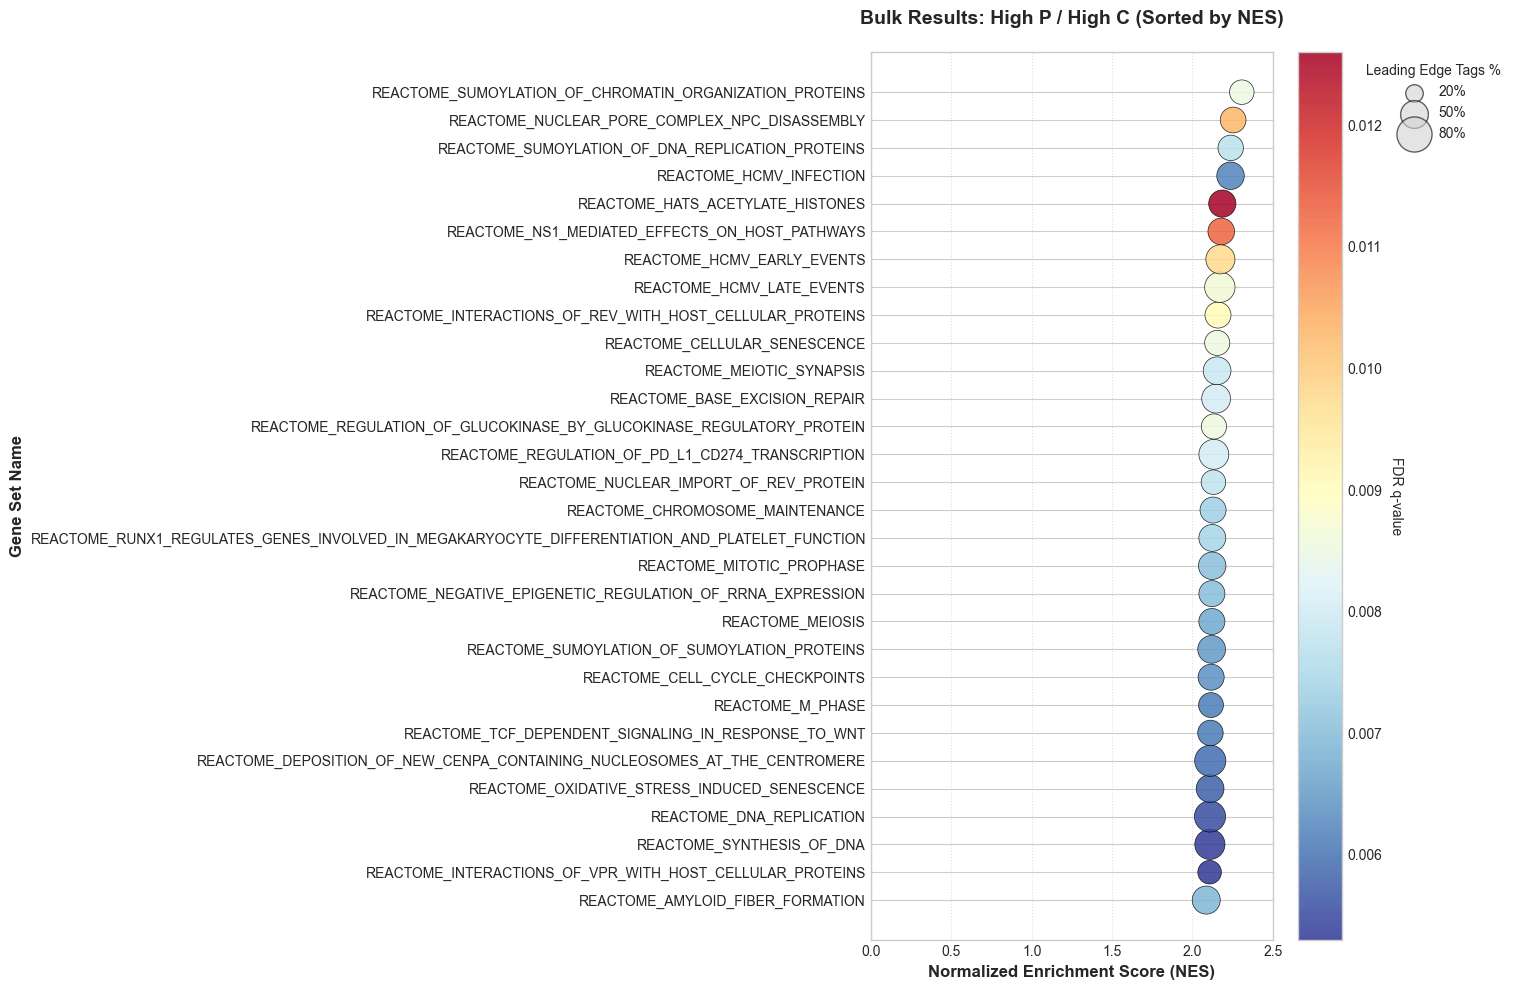

In [7]:


def plot_sorted_gsea(df, title="GSEA Pathway Enrichment", top_n=30):
    # 1. Prepare and Clean Data
    df = df.copy()
    
    # Extract % from 'LEADING EDGE' (e.g., "tags=35%")
    df['Pct_Enriched'] = df['LEADING EDGE'].str.extract(r'tags=(\d+)%').astype(float)
    
    # 2. SORT BY NES
    # We sort ascending=True so that the highest NES appears at the top of the y-axis
    df = df.sort_values('NES', ascending=True).tail(top_n)

    # 3. Create the Visualization
    plt.figure(figsize=(15, 10))
    
    # Create the scatter/bubble plot
    # x = NES (Magnitude)
    # y = NAME (Pathways, now sorted by NES)
    # size = Pct_Enriched (Breadth)
    # color = FDR q-val (Significance)
    scatter = plt.scatter(
        x=df['NES'], 
        y=df['NAME'], 
        s=df['Pct_Enriched'] * 8,        # Scale bubble size
        c=df['FDR q-val'],               # Color by FDR
        cmap='RdYlBu_r',                 # Red-Yellow-Blue palette
        alpha=0.85, 
        edgecolors="black",
        linewidths=0.5
    )


    plt.xlim(0,2.5)
    # 4. Add Aesthetics and Legend
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Normalized Enrichment Score (NES)', fontsize=12, fontweight='bold')

    plt.ylabel('Gene Set Name', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    
    # Add a colorbar for FDR significance
    cbar = plt.colorbar(scatter)
    cbar.set_label('FDR q-value', rotation=270, labelpad=15)
    
    # Create a custom legend for bubble sizes (Percentage of Genes)
    for p in [20, 50, 80]:
        plt.scatter([], [], s=p*8, c='lightgray', alpha=0.6, label=f'{p}%', edgecolors='black')
    
    plt.legend(title="Leading Edge Tags %", loc='upper left', bbox_to_anchor=(1.2, 1), frameon=False)

    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Apply to your dataframes
plot_sorted_gsea(tumor_gsea_results, title="Tumor Results: High P / High C (Sorted by NES)")
plot_sorted_gsea(raw_gsea_results, title="Bulk Results: High P / High C (Sorted by NES)")

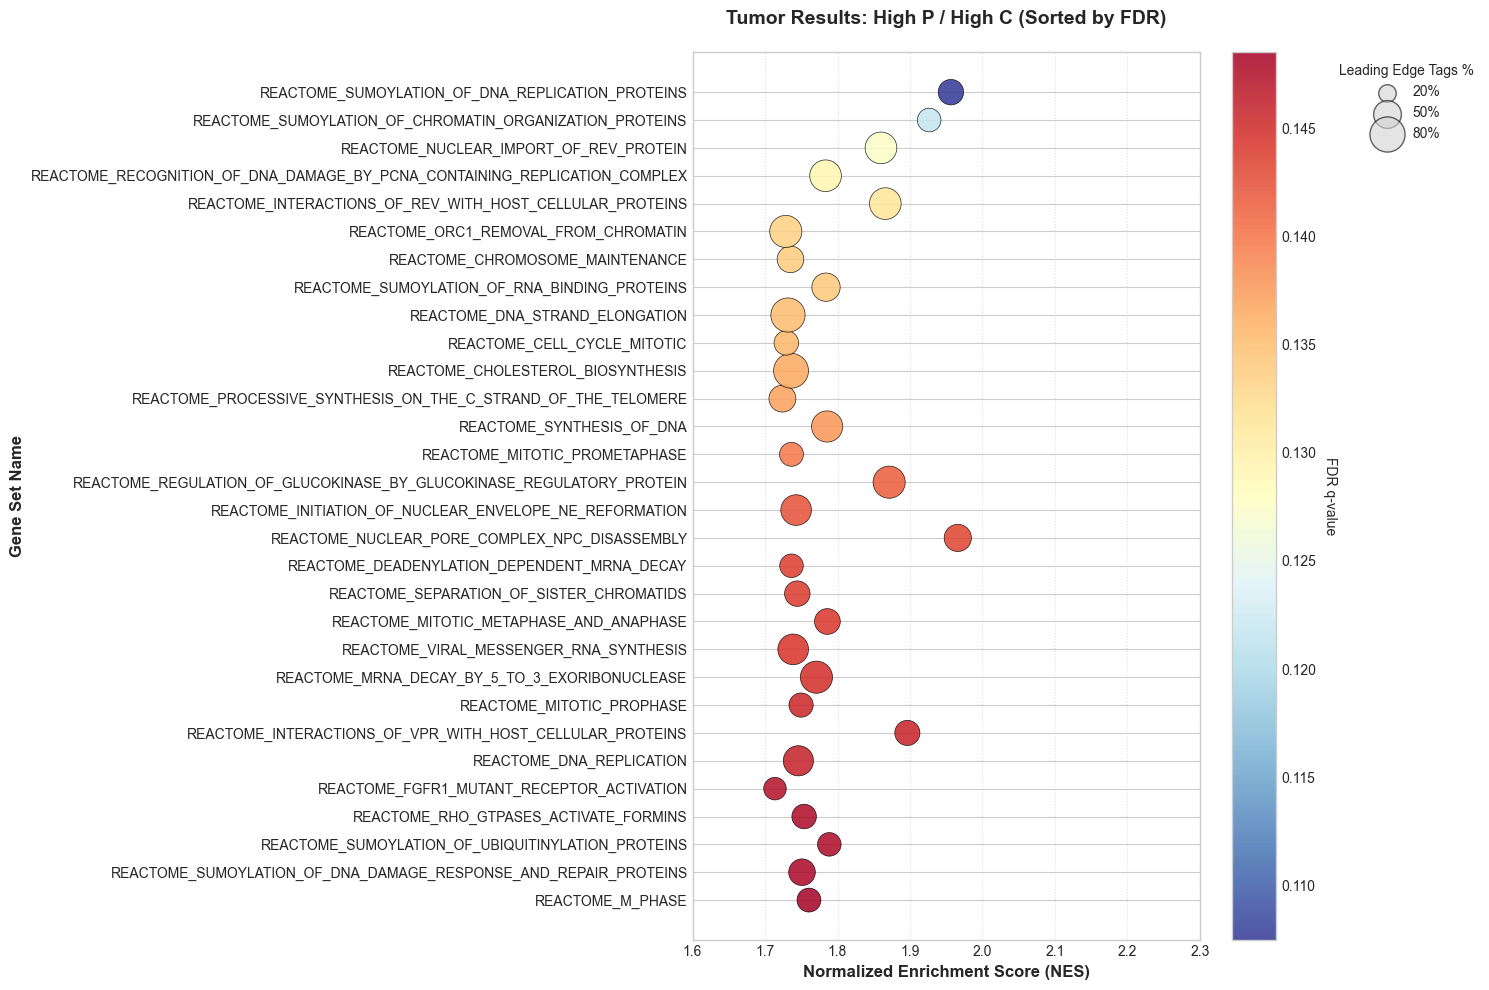

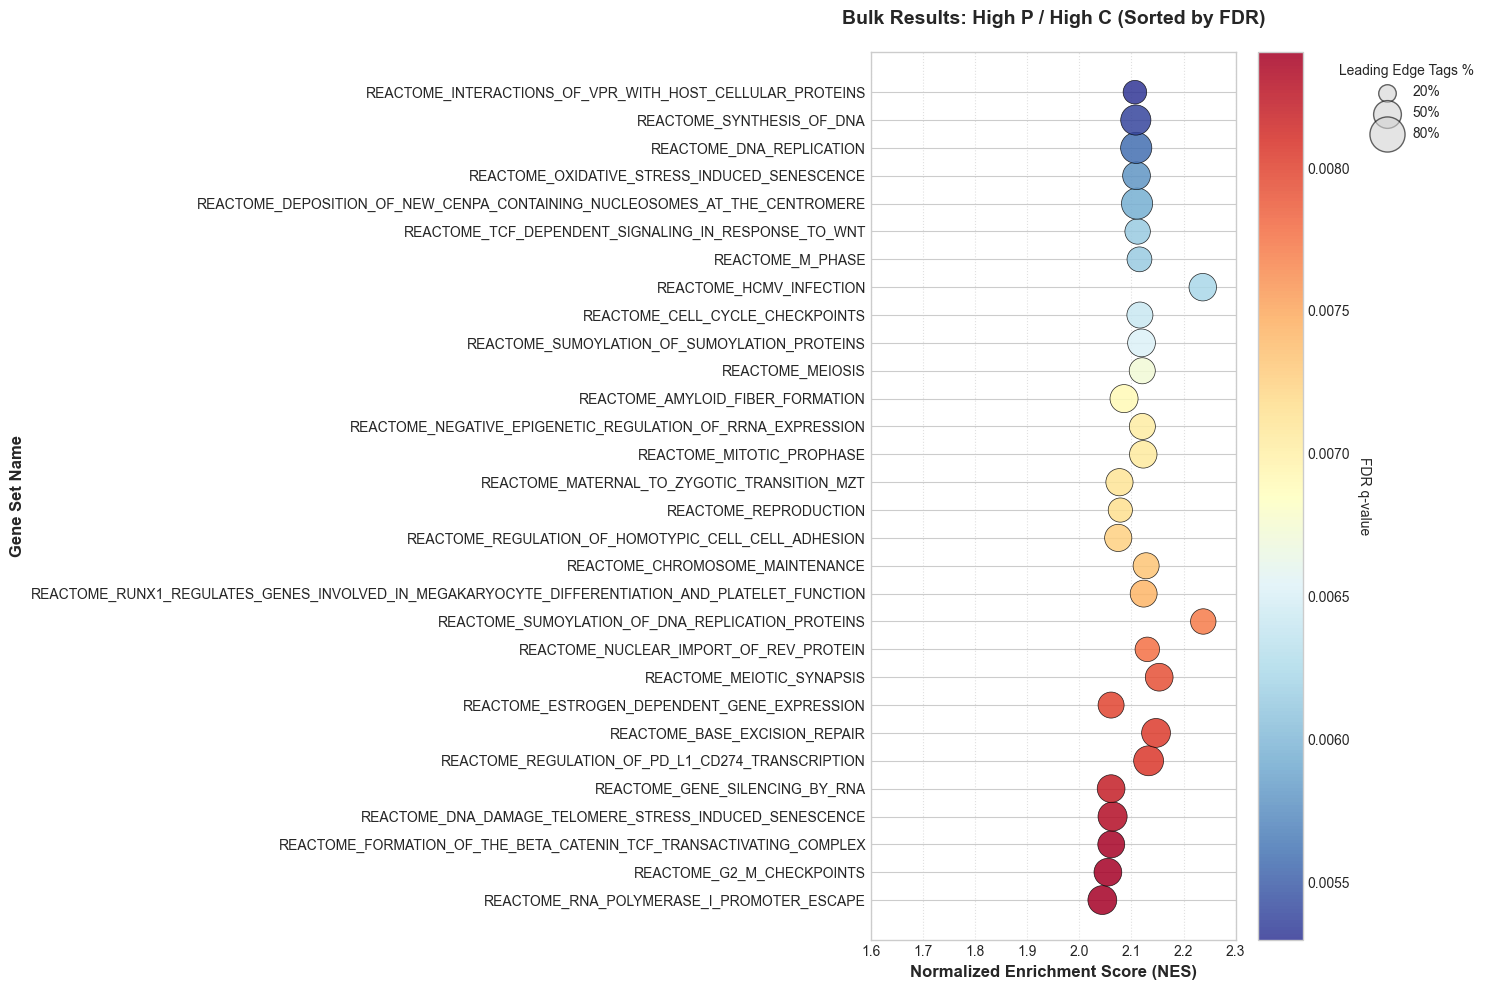

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_sorted_gsea(df, title="GSEA Pathway Enrichment", top_n=30):
    # 1. Prepare and Clean Data
    df = df.copy()
    
    # Extract % from 'LEADING EDGE' (e.g., "tags=35%")
    df['Pct_Enriched'] = df['LEADING EDGE'].str.extract(r'tags=(\d+)%').astype(float)
    
    # 2. SORT BY FDR (Significance)
    # Smaller FDR is more significant. We sort descending so the smallest 
    # FDR values are at the "tail" (which becomes the top of the y-axis).
    df = df.sort_values('FDR q-val', ascending=False).tail(top_n)

    # 3. Create the Visualization
    plt.figure(figsize=(15, 10))
    
    # Create the scatter/bubble plot
    scatter = plt.scatter(
        x=df['NES'], 
        y=df['NAME'], 
        s=df['Pct_Enriched'] * 8,        
        c=df['FDR q-val'],               
        cmap='RdYlBu_r',                 # Red = Low FDR (Significant), Blue = High FDR
        alpha=0.85, 
        edgecolors="black",
        linewidths=0.5
    )

    # Dynamic XLIM based on data magnitude
    plt.xlim(1.6, 2.3)
    
    # 4. Add Aesthetics and Legend
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Normalized Enrichment Score (NES)', fontsize=12, fontweight='bold')
    plt.ylabel('Gene Set Name', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    
    # Add a colorbar for FDR significance
    cbar = plt.colorbar(scatter)
    cbar.set_label('FDR q-value', rotation=270, labelpad=15)
    
    # Create a custom legend for bubble sizes
    for p in [20, 50, 80]:
        plt.scatter([], [], s=p*8, c='lightgray', alpha=0.6, label=f'{p}%', edgecolors='black')
    
    plt.legend(title="Leading Edge Tags %", loc='upper left', bbox_to_anchor=(1.25, 1), frameon=False)

    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Apply to your dataframes - updated titles to reflect sorting change
plot_sorted_gsea(tumor_gsea_results, title="Tumor Results: High P / High C (Sorted by FDR)")
plot_sorted_gsea(raw_gsea_results, title="Bulk Results: High P / High C (Sorted by FDR)")

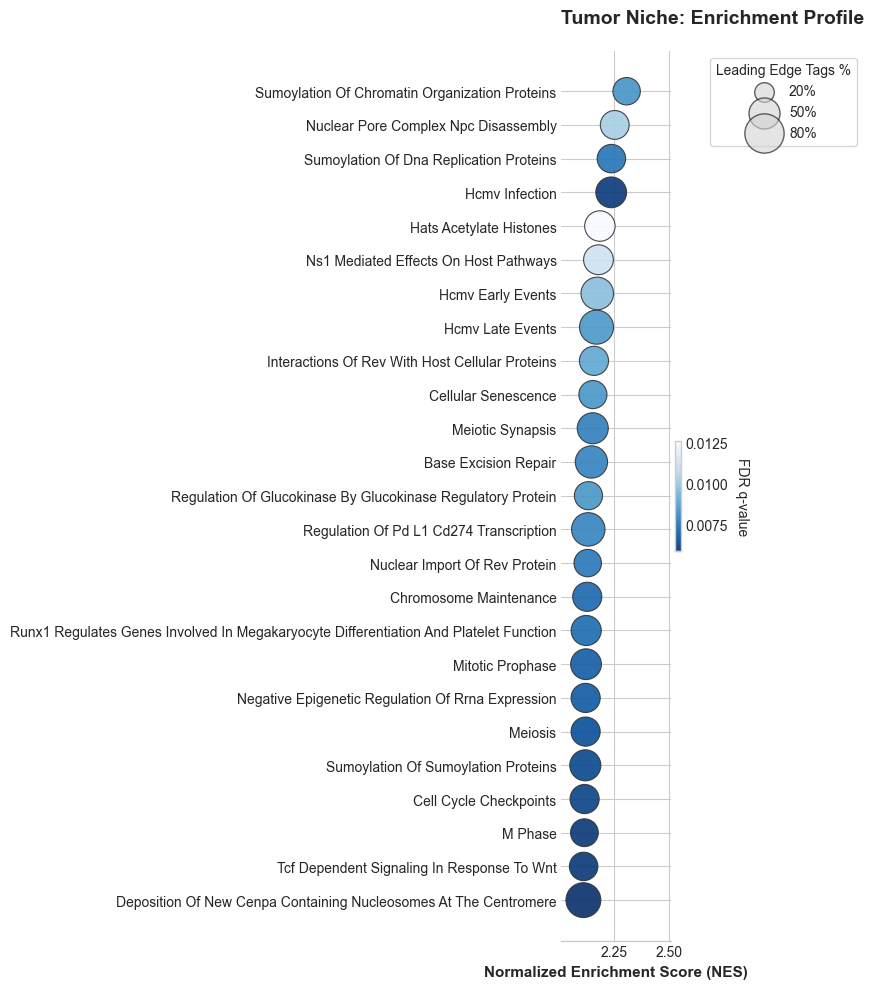

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_thesis_gsea(df, title="Pathway Enrichment in High-Proliferation HGSC Niches", top_n=25):
    # 1. Clean and Prepare Data
    df = df.copy()
    
    # Extract Leading Edge %
    df['Pct_Enriched'] = df['LEADING EDGE'].str.extract(r'tags=(\d+)%').astype(float)
    
    # CLEAN NAMES: Remove "REACTOME_", replace underscores with spaces, and Title Case
    df['NAME'] = df['NAME'].str.replace('REACTOME_', '', regex=False)
    df['NAME'] = df['NAME'].str.replace('_', ' ').str.title()
    
    # 2. Sort by NES for better visual flow
    df = df.sort_values('NES', ascending=True).tail(top_n)

    # 3. Design Aesthetics
    plt.style.use('seaborn-v0_8-whitegrid') # Cleaner background
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Use a sequential colormap (Blues or Viridis) for FDR
    # This is often preferred in modern journals over RdYlBu for single-direction significance
    scatter = ax.scatter(
        x=df['NES'], 
        y=df['NAME'], 
        s=df['Pct_Enriched'] * 10, # Slightly larger for readability
        c=df['FDR q-val'], 
        cmap='Blues_r',           # Darker blue = more significant
        alpha=0.9, 
        edgecolors="0.2",
        linewidths=0.8
    )

    # 4. Axes and Limits
    # Dynamically set x-axis to zoom in on relevant NES scores
    ax.set_xlim(df['NES'].min() - 0.1, df['NES'].max() + 0.2)
    
    ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=11, fontweight='bold')
    ax.set_ylabel('', fontsize=11) # Clearer without 'Gene Set Name' label
    ax.set_title(title, fontsize=14, pad=20, fontweight='bold', loc='left')
    
    # 5. Legend and Colorbar
    cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
    cbar.set_label('FDR q-value', rotation=270, labelpad=15, fontsize=10)
    
    # Custom bubble legend
    handles, labels = [], []
    for p in [20, 50, 80]:
        line = ax.scatter([], [], s=p*10, c='lightgray', alpha=0.6, edgecolors='black')
        handles.append(line)
        labels.append(f'{p}%')
    
    ax.legend(handles, labels, title="Leading Edge Tags %", 
              loc='upper left', bbox_to_anchor=(1.3, 1), 
              frameon=True, fontsize=10)

    # Remove top and right spines for a "Nature" style look
    sns.despine(left=True, bottom=False)
    
    plt.tight_layout()
    return fig

# Execute
fig1 = plot_thesis_gsea(raw_gsea_results, title="Tumor Niche: Enrichment Profile")
plt.show()

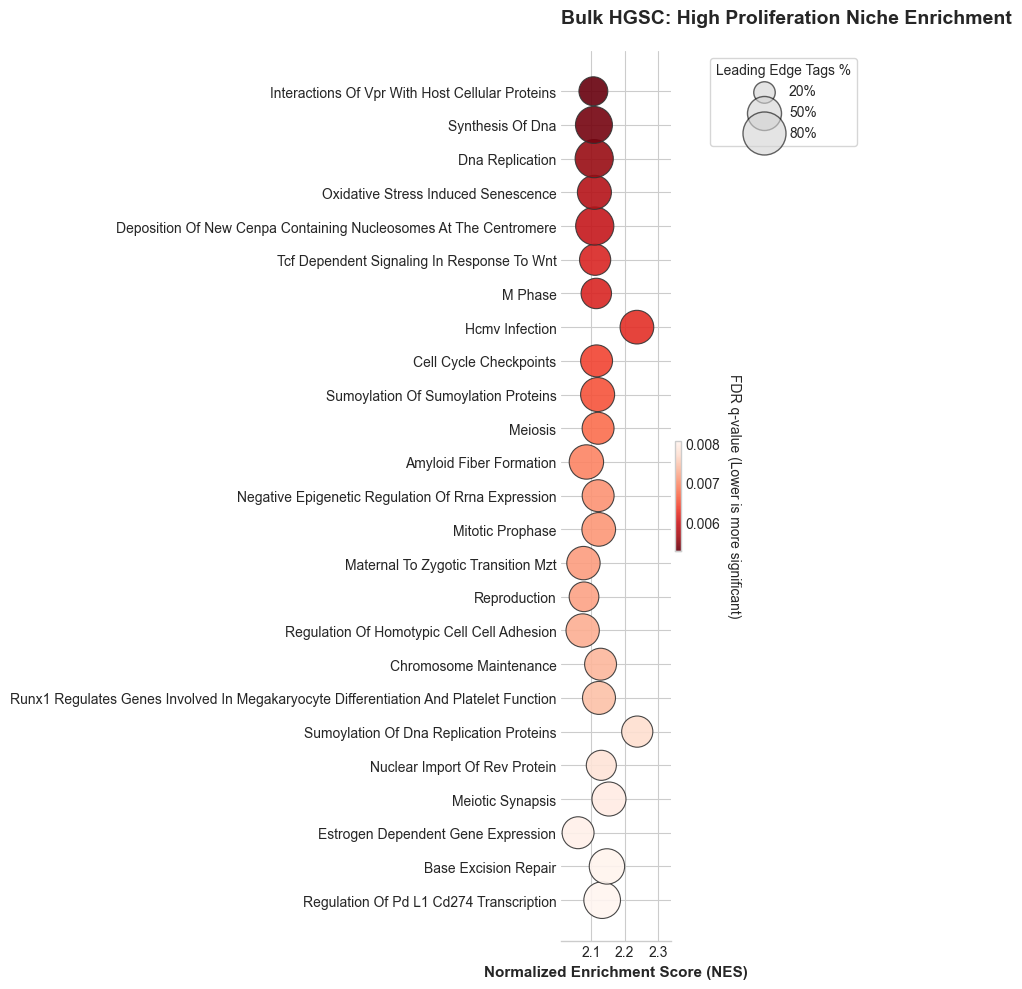

In [10]:


def plot_thesis_gsea(df, title="Pathway Enrichment in High-Proliferation HGSC Niches", top_n=25):
    # 1. Clean and Prepare Data
    df = df.copy()
    
    # Extract Leading Edge %
    df['Pct_Enriched'] = df['LEADING EDGE'].str.extract(r'tags=(\d+)%').astype(float)
    
    # CLEAN NAMES: Remove "REACTOME_", replace underscores with spaces, and Title Case
    df['NAME'] = df['NAME'].str.replace('REACTOME_', '', regex=False)
    df['NAME'] = df['NAME'].str.replace('_', ' ').str.title()
    
    # 2. SORT BY FDR (Significance)
    # Sorting ascending=False so the smallest FDR (most significant) 
    # ends up at the TOP of the y-axis plot.
    df = df.sort_values('FDR q-val', ascending=False).tail(top_n)

    # 3. Design Aesthetics
    plt.style.use('seaborn-v0_8-whitegrid') 
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # PALETTE ADJUSTMENT: Reds_r makes low values (significant) dark red
    # Use 'YlOrRd_r' if you want a transition from yellow to deep red
    scatter = ax.scatter(
        x=df['NES'], 
        y=df['NAME'], 
        s=df['Pct_Enriched'] * 12, # Slightly larger for impact
        c=df['FDR q-val'], 
        cmap='Reds_r',            
        alpha=0.9, 
        edgecolors="0.2",
        linewidths=0.8
    )

    # 4. Axes and Limits
    # Keep the focus on the NES range
    ax.set_xlim(df['NES'].min() - 0.05, df['NES'].max() + 0.1)
    
    ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=11, fontweight='bold')
    ax.set_ylabel('', fontsize=11) 
    ax.set_title(title, fontsize=14, pad=20, fontweight='bold', loc='left')
    
    # 5. Legend and Colorbar
    cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
    cbar.set_label('FDR q-value (Lower is more significant)', rotation=270, labelpad=15, fontsize=10)
    
    # Custom bubble legend
    handles, labels = [], []
    for p in [20, 50, 80]:
        line = ax.scatter([], [], s=p*12, c='lightgray', alpha=0.6, edgecolors='black')
        handles.append(line)
        labels.append(f'{p}%')
    
    ax.legend(handles, labels, title="Leading Edge Tags %", 
              loc='upper left', bbox_to_anchor=(1.3, 1), 
              frameon=True, fontsize=10)

    # Styling: Remove top/right spines
    sns.despine(left=True, bottom=False)
    
    plt.tight_layout()
    return fig

# Execute using your bulk results
fig_final = plot_thesis_gsea(raw_gsea_results, title="Bulk HGSC: High Proliferation Niche Enrichment")
plt.show()

TypeError: Legend.__init__() got an unexpected keyword argument 'title_fontweight'

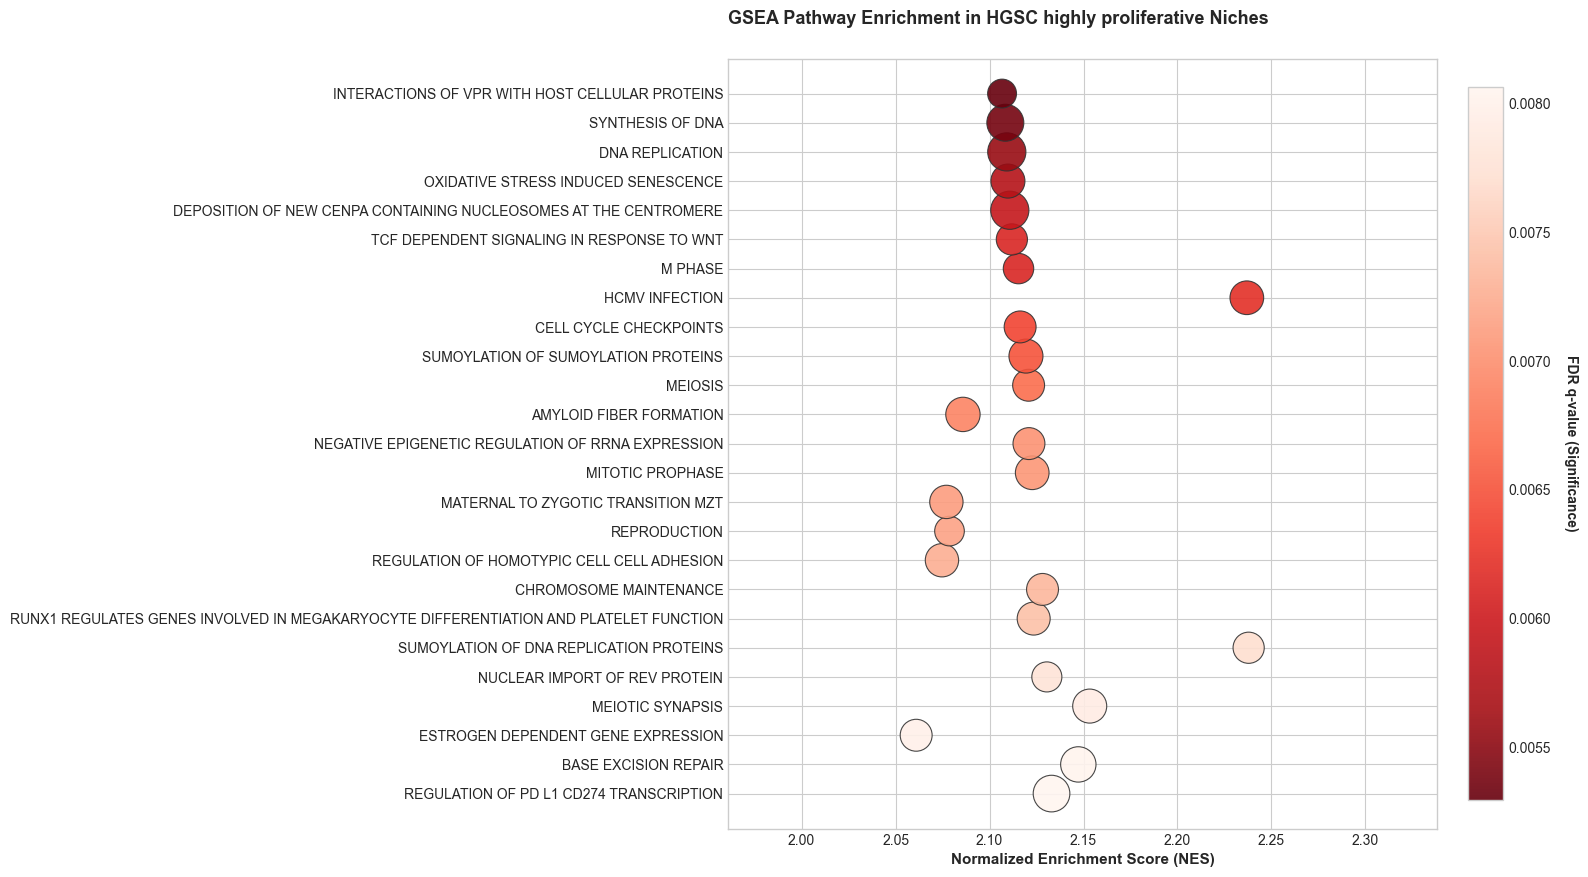

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_thesis_gsea(df, title="GSEA Pathway Enrichment in HGSC highly proliferative Niches", top_n=25):
    # 1. Clean and Prepare Data
    df = df.copy()
    
    # Extract Leading Edge %
    df['Pct_Enriched'] = df['LEADING EDGE'].str.extract(r'tags=(\d+)%').astype(float)
    
    # CLEAN NAMES: Remove "REACTOME_", replace underscores with spaces, and FORCE UPPERCASE
    df['NAME'] = df['NAME'].str.replace('REACTOME_', '', regex=False)
    df['NAME'] = df['NAME'].str.replace('_', ' ').str.upper()
    
    # 2. SORT BY FDR (Significance)
    # tail(top_n) grabs the most significant because we sort descending=False
    df = df.sort_values('FDR q-val', ascending=False).tail(top_n)

    # 3. Design Aesthetics
    plt.style.use('seaborn-v0_8-whitegrid') 
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # PALETTE: Reds_r (Reverse Reds) ensures FDR ~ 0 is dark red
    scatter = ax.scatter(
        x=df['NES'], 
        y=df['NAME'], 
        s=df['Pct_Enriched'] * 12, 
        c=df['FDR q-val'], 
        cmap='Reds_r',            
        alpha=0.9, 
        edgecolors="0.2",
        linewidths=0.8
    )

    # 4. Axes and Limits
    ax.set_xlim(df['NES'].min() - 0.1, df['NES'].max() + 0.1)
    
    # Journal-standard labeling
    ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=11, fontweight='bold')
    ax.set_ylabel('', fontsize=11) 
    
    # Journal titles are usually left-aligned and descriptive
    ax.set_title(title, fontsize=13, pad=25, fontweight='bold', loc='left')
    
    # 5. Legend and Colorbar
    # Using a vertical colorbar with specific significance labeling
    cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
    cbar.set_label('FDR q-value (Significance)', rotation=270, labelpad=20, fontsize=10, fontweight='bold')
    
    # Custom bubble legend for Leading Edge
    handles, labels = [], []
    for p in [20, 50, 80]:
        line = ax.scatter([], [], s=p*12, c='white', alpha=0.6, edgecolors='black')
        handles.append(line)
        labels.append(f'{p}%')
    
    ax.legend(handles, labels, title="LEADING EDGE %", 
              loc='upper left', bbox_to_anchor=(1.25, 1), 
              frameon=True, fontsize=10, title_fontweight='bold')

    # Remove top/right spines for a clean "Nature/Science" look
    sns.despine(left=True, bottom=False)
    
    plt.tight_layout()
    return fig

# Execute
# Note: "raw_gsea_results" should be your dataframe name
fig_final = plot_thesis_gsea(raw_gsea_results)
plt.show()

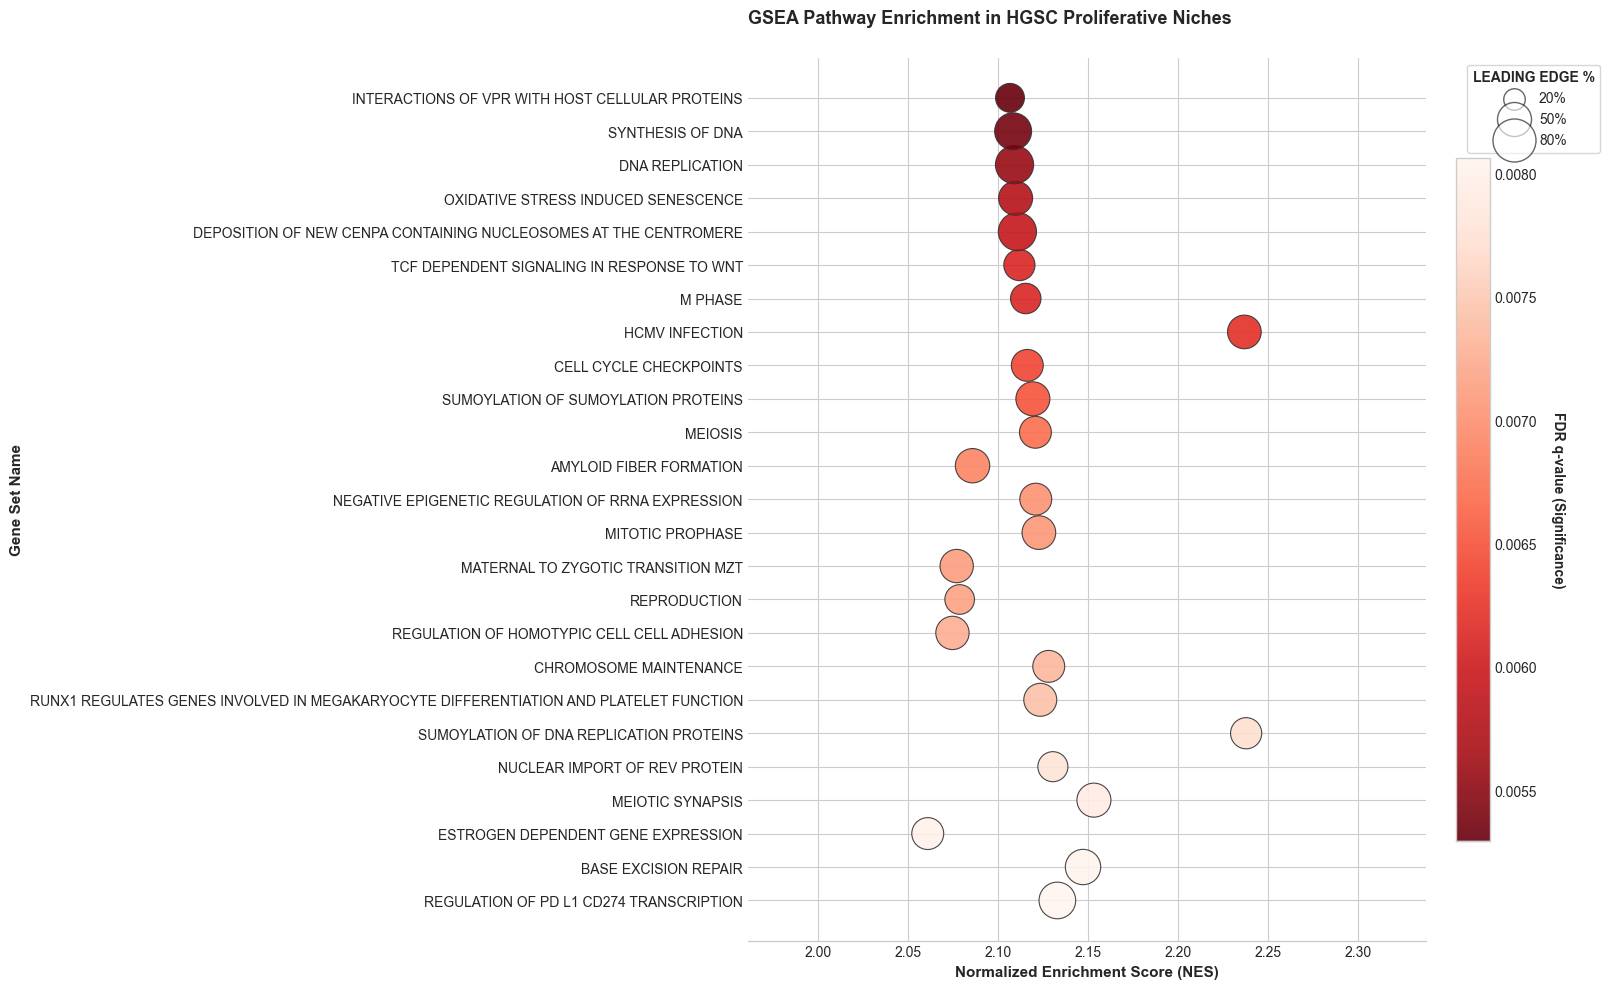

In [14]:


def plot_thesis_gsea(df, title="GSEA Pathway Enrichment in HGSC Proliferative Niches", top_n=25):
    # 1. Clean and Prepare Data
    df = df.copy()
    
    # Extract Leading Edge %
    df['Pct_Enriched'] = df['LEADING EDGE'].str.extract(r'tags=(\d+)%').astype(float)
    
    # CLEAN NAMES: Remove "REACTOME_", replace underscores, and FORCE UPPERCASE
    df['NAME'] = df['NAME'].str.replace('REACTOME_', '', regex=False)
    df['NAME'] = df['NAME'].str.replace('_', ' ').str.upper()
    
    # 2. SORT BY FDR (Significance)
    df = df.sort_values('FDR q-val', ascending=False).tail(top_n)

    # 3. Design Aesthetics
    plt.style.use('seaborn-v0_8-whitegrid') 
    fig, ax = plt.subplots(figsize=(16, 10)) # Increased width for ALL CAPS labels
    
    scatter = ax.scatter(
        x=df['NES'], 
        y=df['NAME'], 
        s=df['Pct_Enriched'] * 12, 
        c=df['FDR q-val'], 
        cmap='Reds_r',            
        alpha=0.9, 
        edgecolors="0.2",
        linewidths=0.8
    )

    # 4. Axes and Limits
    ax.set_xlim(df['NES'].min() - 0.1, df['NES'].max() + 0.1)
    ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Gene Set Name', fontsize=11,fontweight='bold' ) 
    ax.set_title(title, fontsize=13, pad=25, fontweight='bold', loc='left')
    
    # 5. Colorbar
    cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
    cbar.set_label('FDR q-value (Significance)', rotation=270, labelpad=20, fontsize=10, fontweight='bold')
    
    # 6. Legend (FIXED)
    handles, labels = [], []
    for p in [20, 50, 80]:
        line = ax.scatter([], [], s=p*12, c='white', alpha=0.6, edgecolors='black')
        handles.append(line)
        labels.append(f'{p}%')
    
    # Remove 'title_fontweight' from here to avoid the TypeError
    leg = ax.legend(handles, labels, title="LEADING EDGE %", 
                    loc='upper left', bbox_to_anchor=(1.05, 1), 
                    frameon=True, fontsize=10)
    
    # Set the title to bold manually
    plt.setp(leg.get_title(), fontweight='bold')

    # Styling: Remove top/right spines
    sns.despine(left=True, bottom=False)
    
    plt.tight_layout()
    return fig

# Execute
fig_final = plot_thesis_gsea(raw_gsea_results)
plt.show()

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_1859/2678247198.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df['NAME'], fontweight='bold', fontsize=10)


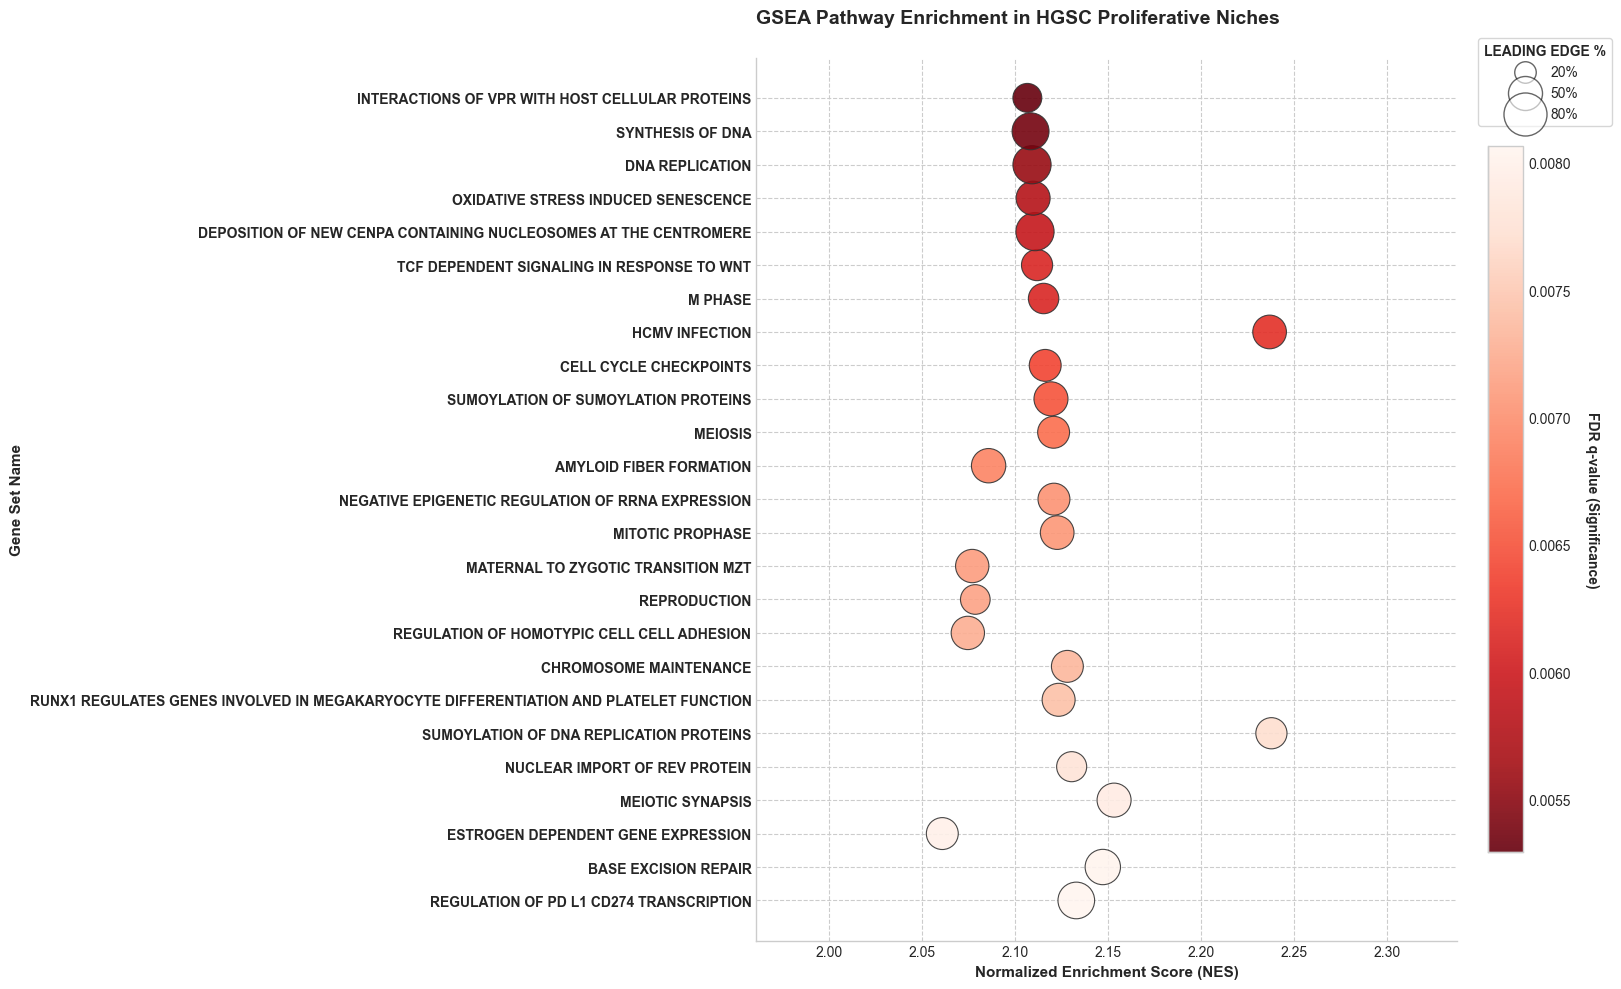

In [ ]:


def plot_thesis_gsea(df, title="GSEA Pathway Enrichment in HGSC Proliferative Niches", top_n=25):
    # 1. Clean and Prepare Data
    df = df.copy()
    
    # Extract Leading Edge %
    df['Pct_Enriched'] = df['LEADING EDGE'].str.extract(r'tags=(\d+)%').astype(float)
    
    # CLEAN NAMES: Remove prefix, underscores, and FORCE UPPERCASE
    df['NAME'] = df['NAME'].str.replace('REACTOME_', '', regex=False)
    df['NAME'] = df['NAME'].str.replace('_', ' ').str.upper()
    
    # 2. SORT BY FDR (Significance)
    df = df.sort_values('FDR q-val', ascending=False).tail(top_n)

    # 3. Design Aesthetics
    # Use a basic style then customize grid for homogeneity
    plt.style.use('seaborn-v0_8-whitegrid') 
    fig, ax = plt.subplots(figsize=(16, 10)) 
    
    # 4. Homogenous Grid Configuration
    # This ensures both X and Y axes have consistent grid lines
    ax.grid(True, which='major', axis='both', linestyle='--', alpha=1, zorder=0)
    
    scatter = ax.scatter(
        x=df['NES'], 
        y=df['NAME'], 
        s=df['Pct_Enriched'] * 12, 
        c=df['FDR q-val'], 
        cmap='Reds_r',            
        alpha=0.9, 
        edgecolors="0.2",
        linewidths=0.8,
        zorder=3 # Ensures dots stay ABOVE grid lines
    )

    # 5. Bold Pathway Titles (Y-axis Ticks)
    # We set the tick labels manually to bold them
    ax.set_yticklabels(df['NAME'], fontweight='bold', fontsize=10)

    # 6. Axes and Limits
    ax.set_xlim(df['NES'].min() - 0.1, df['NES'].max() + 0.1)
    ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Gene Set Name', fontsize=11, fontweight='bold') 
    ax.set_title(title, fontsize=14, pad=25, fontweight='bold', loc='left')
    
    # 7. Colorbar
    cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
    cbar.set_label('FDR q-value (Significance)', rotation=270, labelpad=20, fontsize=10, fontweight='bold')
    
    # 8. Legend
    handles, labels = [], []
    for p in [20, 50, 80]:
        line = ax.scatter([], [], s=p*12, c='white', alpha=0.6, edgecolors='black')
        handles.append(line)
        labels.append(f'{p}%')
    
    leg = ax.legend(handles, labels, title="LEADING EDGE %", 
                    loc='upper left', bbox_to_anchor=(1.02, 1.03), 
                    frameon=True, fontsize=10)
    plt.setp(leg.get_title(), fontweight='bold')

    # Styling: Remove top/right spines
    sns.despine(left=False, bottom=False) # Keep left spine to anchor the bold labels
    
    plt.tight_layout()
    return fig

# Execute
# Ensure raw_gsea_results is defined in your environment
fig_final = plot_thesis_gsea(raw_gsea_results)
plt.show()

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_2271/2559808119.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df['NAME'], fontweight='bold', fontsize=10)


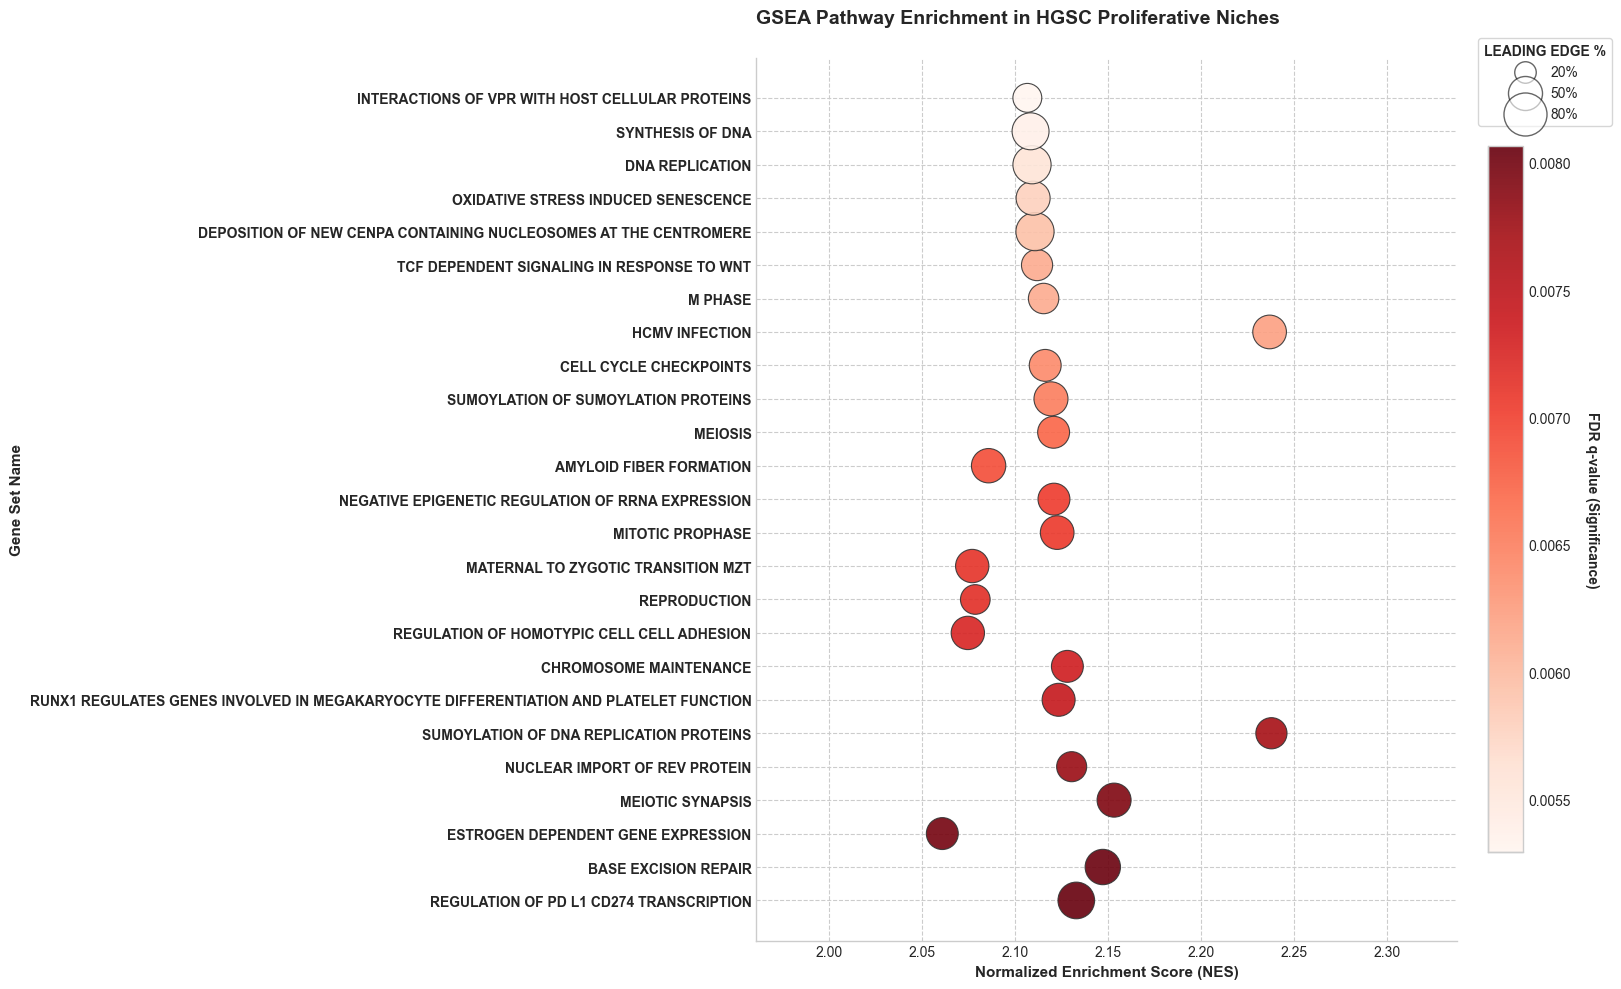

In [17]:
def plot_thesis_gsea(df, title="GSEA Pathway Enrichment in HGSC Proliferative Niches", top_n=25):
    # 1. Clean and Prepare Data
    df = df.copy()
    
    # Extract Leading Edge %
    df['Pct_Enriched'] = df['LEADING EDGE'].str.extract(r'tags=(\d+)%').astype(float)
    
    # CLEAN NAMES: Remove prefix, underscores, and FORCE UPPERCASE
    df['NAME'] = df['NAME'].str.replace('REACTOME_', '', regex=False)
    df['NAME'] = df['NAME'].str.replace('_', ' ').str.upper()
    
    # 2. SORT BY FDR (Significance)
    df = df.sort_values('FDR q-val', ascending=False).tail(top_n)

    # 3. Design Aesthetics
    # Use a basic style then customize grid for homogeneity
    plt.style.use('seaborn-v0_8-whitegrid') 
    fig, ax = plt.subplots(figsize=(16, 10)) 
    
    # 4. Homogenous Grid Configuration
    # This ensures both X and Y axes have consistent grid lines
    ax.grid(True, which='major', axis='both', linestyle='--', alpha=1, zorder=0)
    
    scatter = ax.scatter(
        x=df['NES'], 
        y=df['NAME'], 
        s=df['Pct_Enriched'] * 12, 
        c=df['FDR q-val'], 
        cmap='Reds',              # <--- CHANGED FROM 'Reds_r' TO 'Reds'
        alpha=0.9, 
        edgecolors="0.2",
        linewidths=0.8,
        zorder=3 # Ensures dots stay ABOVE grid lines
    )

    # 5. Bold Pathway Titles (Y-axis Ticks)
    # We set the tick labels manually to bold them
    ax.set_yticklabels(df['NAME'], fontweight='bold', fontsize=10)

    # 6. Axes and Limits
    ax.set_xlim(df['NES'].min() - 0.1, df['NES'].max() + 0.1)
    ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Gene Set Name', fontsize=11, fontweight='bold') 
    ax.set_title(title, fontsize=14, pad=25, fontweight='bold', loc='left')
    
    # 7. Colorbar
    cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
    cbar.set_label('FDR q-value (Significance)', rotation=270, labelpad=20, fontsize=10, fontweight='bold')
    
    # 8. Legend
    handles, labels = [], []
    for p in [20, 50, 80]:
        line = ax.scatter([], [], s=p*12, c='white', alpha=0.6, edgecolors='black')
        handles.append(line)
        labels.append(f'{p}%')
    
    leg = ax.legend(handles, labels, title="LEADING EDGE %", 
                    loc='upper left', bbox_to_anchor=(1.02, 1.03), 
                    frameon=True, fontsize=10)
    plt.setp(leg.get_title(), fontweight='bold')

    # Styling: Remove top/right spines
    sns.despine(left=False, bottom=False) # Keep left spine to anchor the bold labels
    
    plt.tight_layout()
    return fig

# Execute
# Ensure raw_gsea_results is defined in your environment
fig_final = plot_thesis_gsea(raw_gsea_results)
plt.show()